In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('D:\project_5\DATA\Superstore.csv',encoding='latin1')

In [3]:
df['Order Date']=pd.to_datetime(df['Order Date'])

In [8]:
# Total customers
total_customers = df["Customer Name"].nunique()
total_customers

793

In [9]:
# Customer revenue
customer_sales = df.groupby("Customer Name")["Sales"].sum()
customer_sales

Customer Name
Aaron Bergman          886.156
Aaron Hawkins         1744.700
Aaron Smayling        3050.692
Adam Bellavance       7755.620
Adam Hart             3250.337
                        ...   
Xylona Preis          2374.658
Yana Sorensen         6720.444
Yoseph Carroll        5454.350
Zuschuss Carroll      8025.707
Zuschuss Donatelli    1493.944
Name: Sales, Length: 793, dtype: float64

In [15]:
# customer revenue distrubtion
customer_sales = df.groupby('Customer Name')['Sales'].sum()
customer_sales.describe()

count      793.000000
mean      2896.848500
std       2628.670117
min          4.833000
25%       1146.050000
50%       2256.394000
75%       3785.276000
max      25043.050000
Name: Sales, dtype: float64

In [10]:
# Segmentation
segments = pd.qcut(customer_sales, q=3, labels=["Low", "Medium", "High"])
customer_segment = pd.DataFrame({
    "Sales": customer_sales,
    "Segment": segments
})
customer_segment

,Sales,Segment
Customer Name,,
Aaron Bergman,886.156,Low
Aaron Hawkins,1744.700,Medium
Aaron Smayling,3050.692,Medium
Adam Bellavance,7755.620,High
Adam Hart,3250.337,High
...,...,...
Xylona Preis,2374.658,Medium
Yana Sorensen,6720.444,High
Yoseph Carroll,5454.350,High


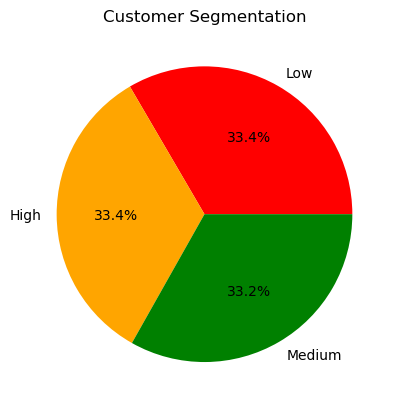

In [14]:
customer_segment["Segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["red","orange","green"]
)
plt.title("Customer Segmentation")
plt.ylabel("")
plt.show()